In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'Airplane','Automobile','Bird','Cat','Deer',
    'Dog','Frog','Horse','Ship','Truck'
]

print("Training Images:", x_train.shape)
print("Testing Images :", x_test.shape)

# Normalize

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 637s 4us/step
Training Images: (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


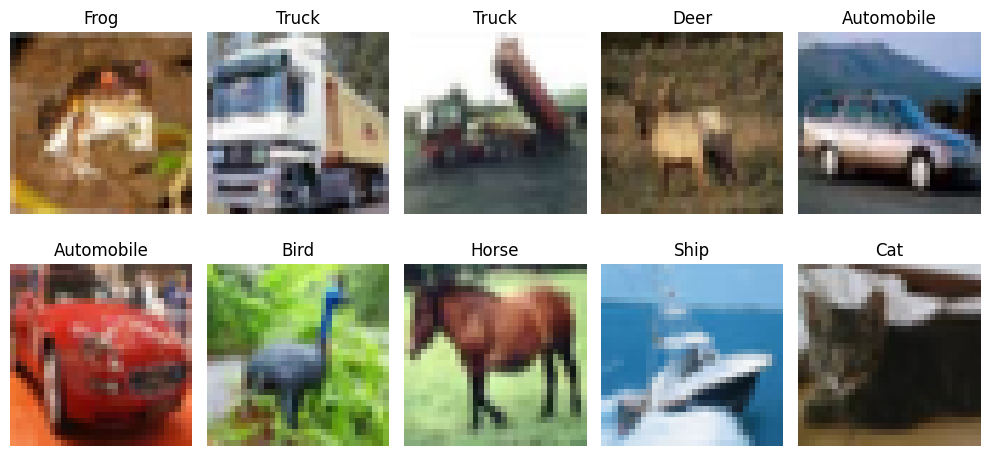

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()



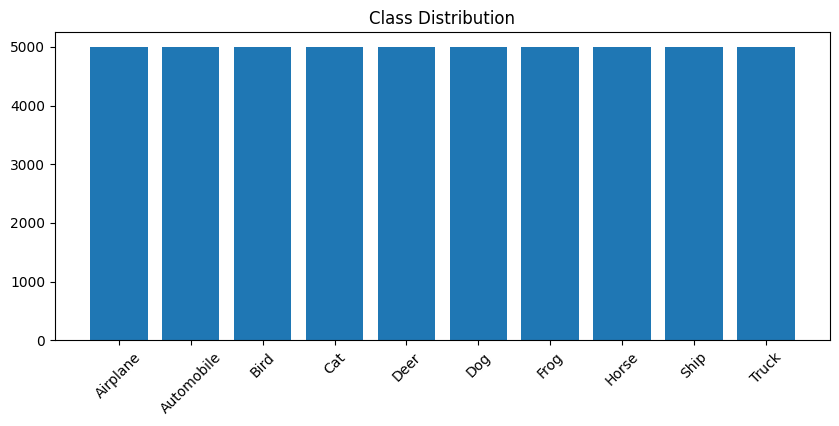

In [5]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,4))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [6]:

FILTERS1 = 32
FILTERS2 = 64
FILTERS3 = 128

KERNEL_SIZE = (3,3)

BATCH_SIZE = 64
EPOCHS = 10


In [8]:

model = models.Sequential()

model.add(layers.Conv2D(FILTERS1,
                        KERNEL_SIZE,
                        activation='relu',
                        padding='same',
                        input_shape=(32,32,3)))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(FILTERS2,
                        KERNEL_SIZE,
                        activation='relu',
                        padding='same'))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(FILTERS3,
                        KERNEL_SIZE,
                        activation='relu',
                        padding='same'))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 156ms/step - accuracy: 0.3753 - loss: 1.6973 - val_accuracy: 0.5140 - val_loss: 1.3407
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.5245 - loss: 1.3247 - val_accuracy: 0.6113 - val_loss: 1.0913
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 147ms/step - accuracy: 0.5909 - loss: 1.1522 - val_accuracy: 0.6466 - val_loss: 0.9904
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 152ms/step - accuracy: 0.6377 - loss: 1.0334 - val_accuracy: 0.6854 - val_loss: 0.8973
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 152ms/step - accuracy: 0.6702 - loss: 0.9386 - val_accuracy: 0.6975 - val_loss: 0.8535
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 147ms/step - accuracy: 0.6962 - loss: 0.8681 - val_accuracy: 0.7189 - val_loss: 0.8083
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.7212 - loss: 0.7896 - val_accuracy: 0.7142 - val_loss: 0.8358
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.7488 - los

In [11]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7345 - loss: 0.8070

Test Accuracy: 0.734499990940094


In [12]:
predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


              precision    recall  f1-score   support

    Airplane       0.79      0.77      0.78      1000
  Automobile       0.88      0.83      0.86      1000
        Bird       0.67      0.59      0.63      1000
         Cat       0.52      0.58      0.55      1000
        Deer       0.70      0.68      0.69      1000
         Dog       0.59      0.66      0.62      1000
        Frog       0.79      0.79      0.79      1000
       Horse       0.77      0.80      0.78      1000
        Ship       0.84      0.86      0.85      1000
       Truck       0.83      0.79      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.74     10000
weighted avg       0.74      0.73      0.74     10000



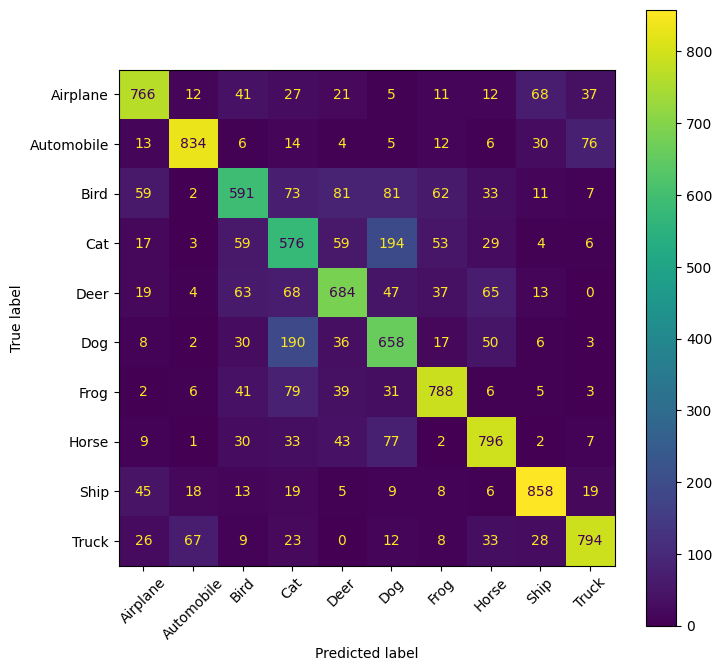

In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()

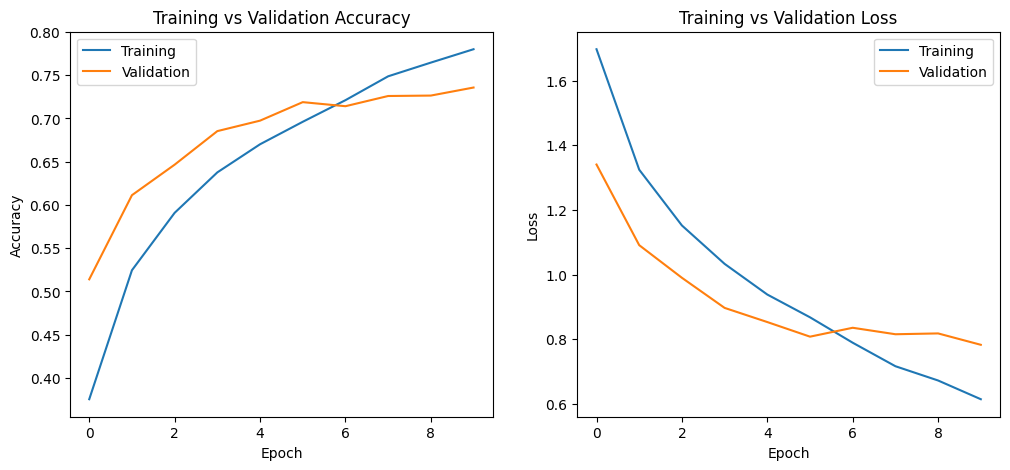

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()


plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


In [16]:
trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_weights]
)

print("\nTrainable Parameters:", trainable_params)



Trainable Parameters: 1143242


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


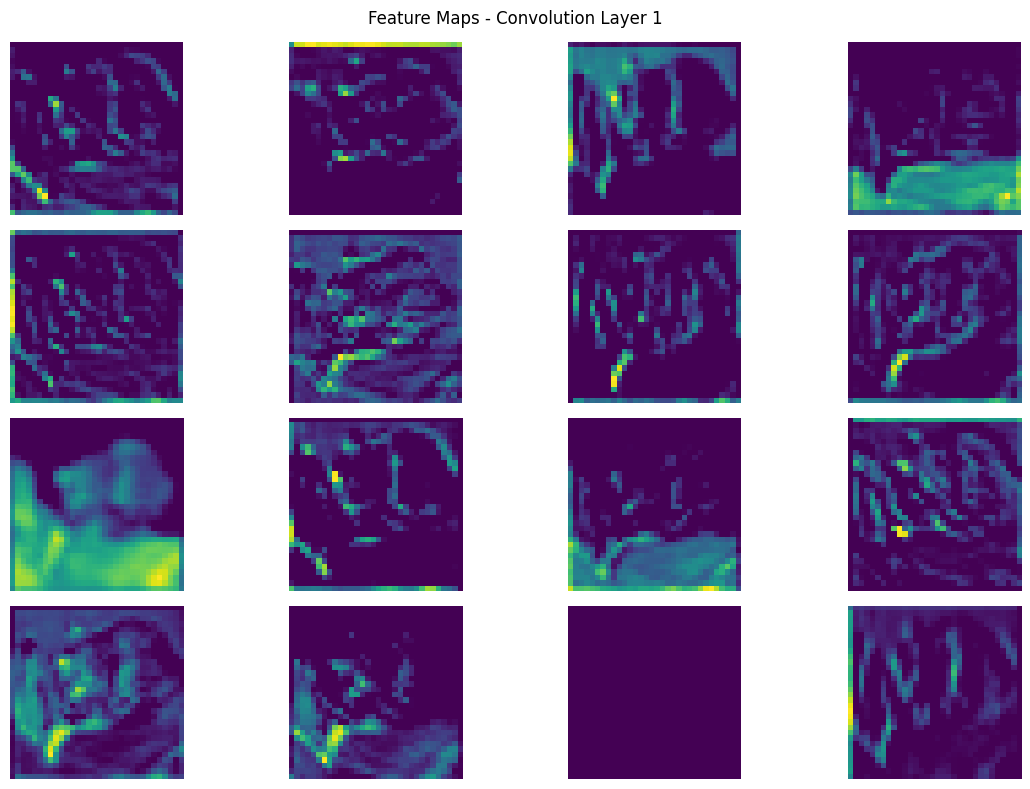

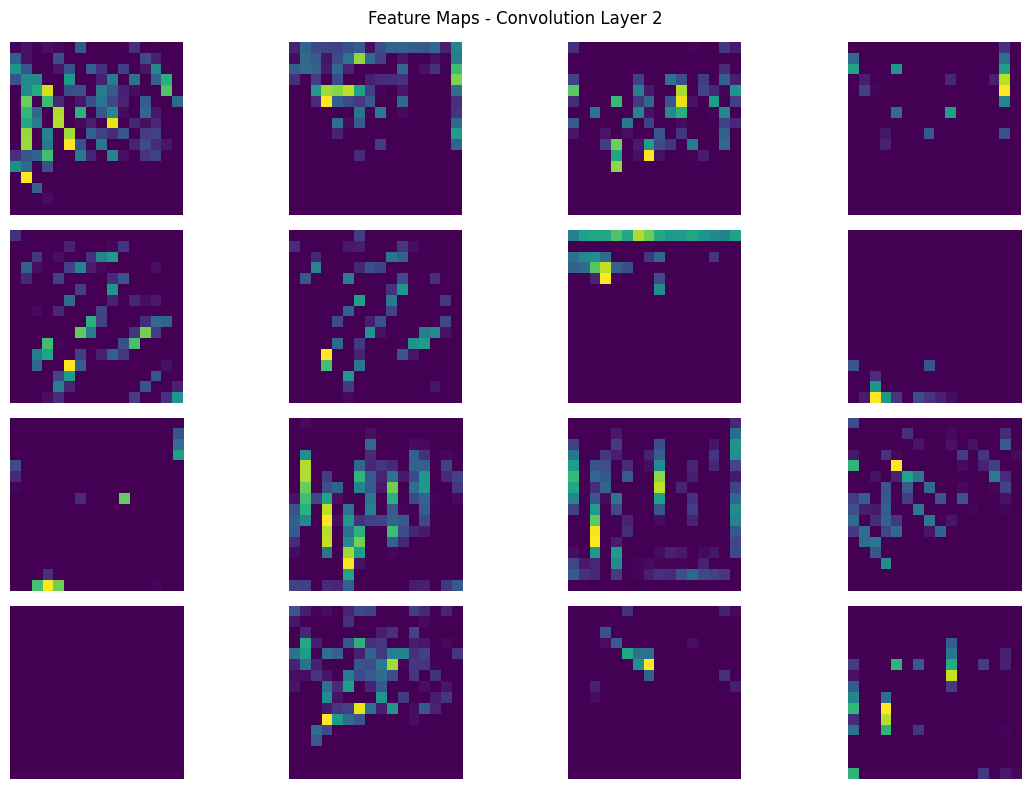

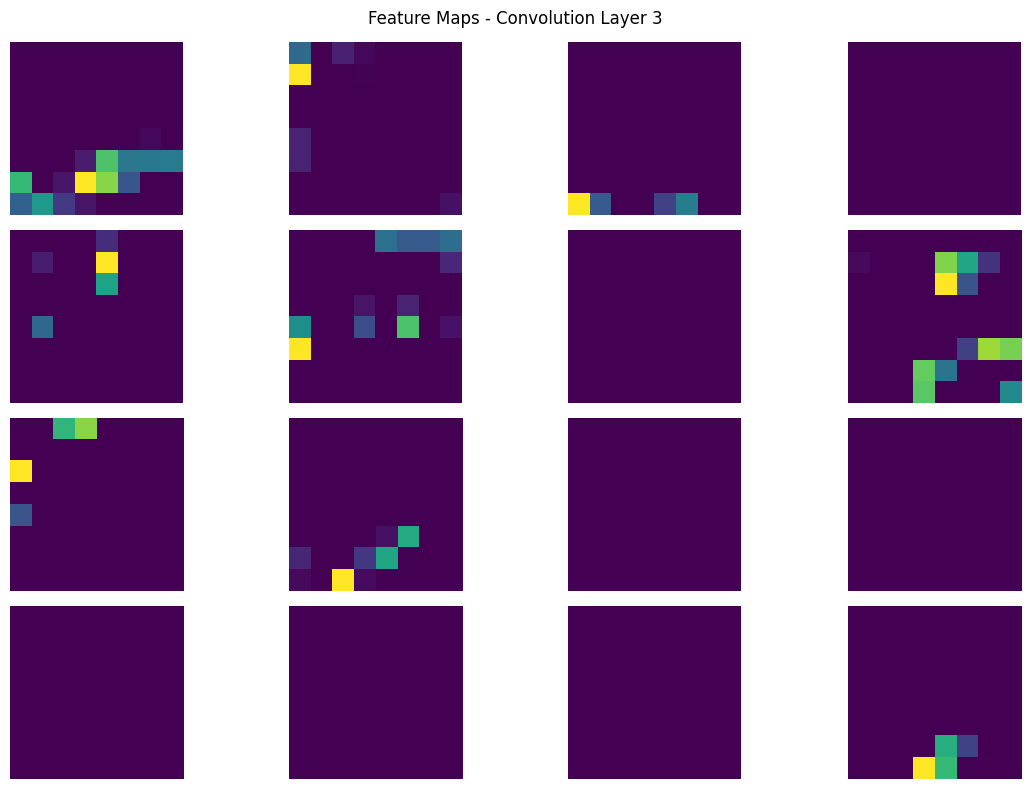

In [18]:

layer_outputs = [layer.output for layer in model.layers
                 if isinstance(layer, layers.Conv2D)]

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)

sample = x_test[0:1]

feature_maps = feature_model.predict(sample)

for layer_num, fmap in enumerate(feature_maps):

    plt.figure(figsize=(12,8))

    num_filters = min(16, fmap.shape[-1])

    for i in range(num_filters):
        plt.subplot(4,4,i+1)
        plt.imshow(fmap[0,:,:,i], cmap='viridis')
        plt.axis("off")

    plt.suptitle(f"Feature Maps - Convolution Layer {layer_num+1}")
    plt.tight_layout()
    plt.show()


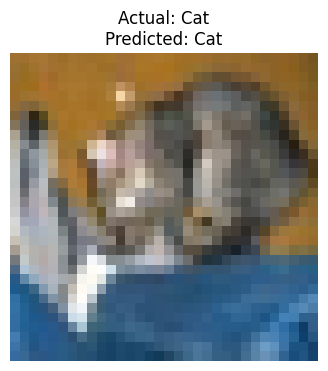

In [19]:
plt.figure(figsize=(6,4))

plt.imshow(x_test[0])

plt.title(
    f"Actual: {class_names[y_test[0][0]]}\n"
    f"Predicted: {class_names[y_pred[0]]}"
)

plt.axis("off")

plt.show()